In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
def check_pin_visibility(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Gaussian Blur (Common step)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Adaptive Threshold
    # Block Size 25, Constant 10 (Fine tune these!)
    adaptive_result = cv2.adaptiveThreshold(blurred, 255, 
                                            cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                            cv2.THRESH_BINARY_INV, 45, 10)

    if os.path.exists("output"):
        cv2.imwrite(f"output/adaptive_{image_path.split('/')[-1]}", adaptive_result)
    else:
        os.mkdir("output")
        cv2.imwrite(f"output/adaptive_{image_path.split('/')[-1]}", adaptive_result)

for img in os.listdir("./data/socket/"):
    check_pin_visibility(f"./data/socket/{img}")

In [3]:
""" def extract_aligned_pins(image_path, coords, crop_size=64):  
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Gentler CLAHE for better details
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(4,4))  # Reduced from (8,8)
    enhanced = clahe.apply(gray)
    
    # Add bilateral filtering to preserve edges
    enhanced = cv2.bilateralFilter(enhanced, 5, 50, 50)
    
    pins = []
    for i, (cx, cy) in enumerate(coords):
        half = crop_size // 2
        if (cy-half >= 0 and cx-half >= 0 and 
            cy+half < enhanced.shape[0] and cx+half < enhanced.shape[1]):
            crop = enhanced[cy-half:cy+half, cx-half:cx+half]
            # Resize to consistent size
            crop = cv2.resize(crop, (256, 256), interpolation=cv2.INTER_CUBIC)
            pins.append((crop, i, cx, cy))
    return pins """

def analyze_data_quality(pins):
    quality_issues = []
    for crop, idx, x, y in pins:
        # Check variance (blurriness)
        variance = cv2.Laplacian(crop, cv2.CV_64F).var()
        if variance < 50:
            quality_issues.append(f"Pin {idx} at ({x},{y}) may be blurry (var={variance:.2f})")
        
        # Check brightness
        mean_brightness = crop.mean()
        if mean_brightness < 30 or mean_brightness > 225:
            quality_issues.append(f"Pin {idx} at ({x},{y}) has extreme brightness ({mean_brightness:.2f})")
    return quality_issues

In [ ]:
def extract_precise_grid_hough(binary_path):
    binary = cv2.imread(binary_path, cv2.IMREAD_GRAYSCALE)
    
    circles = cv2.HoughCircles(
        binary, 
        cv2.HOUGH_GRADIENT, 
        dp=1,           # Inverse ratio of accumulator resolution
        minDist=10,     # Minimum distance between circle centers
        param1=60,      # Upper threshold for edge detection
        param2=10,      # Accumulator threshold for center detection
        minRadius=5,    # Minimum circle radius
        maxRadius=20    # Maximum circle radius
    )
    
    coords = []
    if circles is not None:
        circles = np.round(circles[0, :]).astype("int")
        coords = [(x, y) for x, y in circles[:, :2]]
        print(f"Found {len(coords)} circles with Hough")
    else:
        print("No circles found with Hough!")
    
    return coords

def extract_precise_grid(binary_path):
    binary = cv2.imread(binary_path, cv2.IMREAD_GRAYSCALE)
    
    template_size = 30  # Bigger template
    template = np.zeros((template_size, template_size), dtype=np.uint8)
    cv2.circle(template, (template_size//2, template_size//2), 8, 255, -1)  # Solid circle
    cv2.circle(template, (template_size//2, template_size//2), 12, 0, 3)    # Black ring around it
    
    result = cv2.matchTemplate(binary, template, cv2.TM_CCOEFF_NORMED)
    
    # MUCH higher threshold
    threshold = 0.8  # Increased from 0.7
    locations = np.where(result >= threshold)
    
    # Remove duplicate detections (Non-Maximum Suppression)
    coords_raw = list(zip(locations[1], locations[0]))
    
    # Filter out coordinates that are too close to each other
    coords = []
    min_distance = 20  # Minimum pixels between pin centers
    
    for x, y in coords_raw:
        # Check if this coord is far enough from existing ones
        too_close = False
        for existing_x, existing_y in coords:
            distance = np.sqrt((x - existing_x)**2 + (y - existing_y)**2)
            if distance < min_distance:
                too_close = True
                break
        
        if not too_close:
            coords.append((x, y))
    
    print(f"Found {len(coords)} pins after filtering")
    return coords

def filter_pins_simple_distance(coords, max_neighbor_dist=200):
    filtered_coords = []
    coords_array = np.array(coords)
    
    for i, (x, y) in enumerate(coords):
        # Count neighbors within max_neighbor_dist
        distances = np.sqrt(np.sum((coords_array - [x, y])**2, axis=1))
        neighbors = np.sum(distances < max_neighbor_dist) - 1  # -1 to exclude self
        
        # Keep pins that have at least 8 neighbors (socket pins are densely packed)
        if neighbors >= 8:
            filtered_coords.append((x, y))
    
    print(f"Distance filtering: {len(coords)} -> {len(filtered_coords)} pins")
    return filtered_coords

def extract_aligned_pins(image_path, coords, crop_size=64):
    # Extract pins with better preprocessing
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # CLAHE for better contrast
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(4,4))
    enhanced = clahe.apply(gray)
    
    pins = []
    for i, (cx, cy) in enumerate(coords):
        half = crop_size // 2
        if (cy-half >= 0 and cx-half >= 0 and cy+half < enhanced.shape[0] and cx+half < enhanced.shape[1]): # Boundary check (too close to the edge)
            crop = enhanced[cy-half:cy+half, cx-half:cx+half]
            # Normalize each pin individually
            crop = cv2.normalize(crop, None, 0, 255, cv2.NORM_MINMAX)
            crop = cv2.GaussianBlur(crop, (3,3), 0)
            pins.append((crop, i, cx, cy))

    return pins 

In [5]:
def filter_good_pins(pins, variance_threshold=100):
    """Remove blurry/bad quality pins and not pins (outside pins area in socket)"""
    good_pins = []
    
    """ for crop, idx, x, y in pins:
        # Check if pin is in focus (Laplacian variance)
        variance = cv2.Laplacian(crop, cv2.CV_64F).var()
        
        if variance > variance_threshold:
            good_pins.append((crop, idx, x, y)) """
    
    good_pins = pins
    
    max_dist_pins = 20 # max distance from one pins center to another
    final_good_pins = []
    for i in range(len(good_pins)):
        crop_i, idx_i, x_i, y_i = good_pins[i]
        too_close = False
        for j in range(len(final_good_pins)):
            crop_j, idx_j, x_j, y_j = final_good_pins[j]
            dist = np.sqrt((x_i - x_j)**2 + (y_i - y_j)**2)
            if dist < max_dist_pins: 
                too_close = True 
                break
        if not too_close:
            final_good_pins.append(good_pins[i])
    good_pins = final_good_pins
    print(f"Filtered {len(pins)} -> {len(good_pins)} quality pins")
    return good_pins

def visualize_pin_quality(pins):
    fig, axes = plt.subplots(4, 8, figsize=(16, 8))
    for i, (crop, idx, x, y) in enumerate(pins[:32]):
        row, col = i // 8, i % 8
        axes[row, col].imshow(crop, cmap='gray')
        axes[row, col].set_title(f"{idx}")
        axes[row, col].axis('off')
    plt.show()

def visualize_detection_on_original(image_path, pins):
    img = cv2.imread(image_path)
    vis_img = img.copy()
    crop_size = 32
    coords = [(x, y) for (_, _, x, y) in pins]

    # Draw Bounding Boxes
    half_size = crop_size // 2
    h, w = vis_img.shape[:2] # Get image dimensions

    for (x, y) in coords:
        # Calculate bounding box coordinates
        x1 = x - half_size
        y1 = y - half_size
        x2 = x + half_size
        y2 = y + half_size

        # Green (0, 255, 0), Thickness 2 px
        cv2.rectangle(vis_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        # Optional: Draw a small red dot at the exact center
        cv2.circle(vis_img, (x, y), 2, (0, 0, 255), -1)
        
    # Convert BGR (OpenCV) to RGB (Matplotlib)
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Detection Evaluation: {len(coords)} Pins Detected")
    plt.axis('off')
    plt.show()
    
    return vis_img

Processing WIN_20251217_13_52_19_Pro.jpg...
Found 2100 circles with Hough
Filtered 2062 -> 1943 quality pins


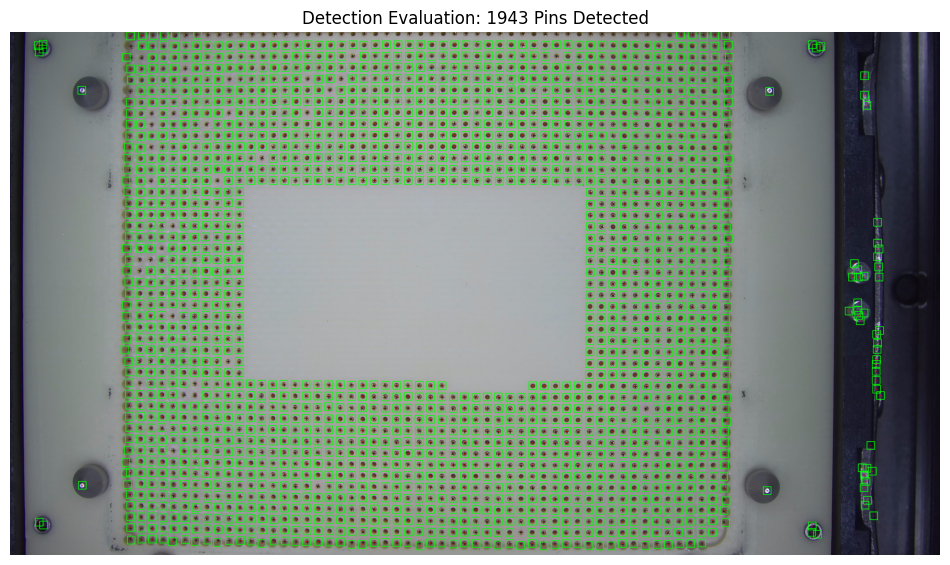

Dataset generated at datasets/socket_pins


In [6]:
# Use the coordinates we found in the previous step
# coords = [(x1,y1), (x2,y2), ...] 

def create_anomalib_dataset(image_path, pins, img_name, output_dir="datasets/socket_pins"):
    img = cv2.imread(image_path)
    
    # Create folders
    train_dir = os.path.join(output_dir, "train/good")
    test_dir = os.path.join(output_dir, "test/good")
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)
    
    for i, (crop, idx, x, y) in enumerate(pins):
        if i < 0.8*len(pins):
            cv2.imwrite(os.path.join(train_dir, f"{img_name}_{idx}.png"), crop)
        else:
            cv2.imwrite(os.path.join(test_dir, f"{img_name}_{idx}.png"), crop)
            
    print(f"Dataset generated at {output_dir}")


for img in os.listdir("./data/socket/"):
    print(f"Processing {img}...")
    
    # Get coordinates from binary image
    binary_path = f"output/adaptive_{img}"
    coords = extract_precise_grid_hough(binary_path)
    # coords = filter_pins_simple_distance(coords, max_neighbor_dist=200)

    # Extract pins from original image
    original_path = f"./data/socket/{img}"
    pins = extract_aligned_pins(original_path, coords)

    # Might crop 64x64 from the high-res image, then resize up, or crop larger.
    """ crop = extract_aligned_pins(original_path, center_x, center_y, size=224)
    if crop is not None:
        # Resize to standard size for ML model (usually 224 or 256)
        crop_resized = cv2.resize(crop, (224, 224))
        cv2.imwrite(f"output/aligned_{img}", crop_resized) """
    
    # Filter and visualize
    pins = filter_good_pins(pins) # Need to work on this
    """ visualize_pin_quality(pins) """
    visualize_detection_on_original(original_path, pins)
    """ analyze_data_quality(pins) """
    
    # Create dataset
    create_anomalib_dataset(original_path, pins, img.split(".")[0])

In [7]:
""" import numpy as np
from sklearn.cluster import DBSCAN

def filter_pins_by_clustering(coords, max_dist=200, min_cluster_size=300):
    if len(coords) == 0:
        return []
    
    # Convert to numpy array for clustering
    coords_array = np.array(coords)
    
    # DBSCAN clustering - groups nearby points together
    clustering = DBSCAN(eps=max_dist, min_samples=min_cluster_size).fit(coords_array)
    labels = clustering.labels_
    
    # Find the largest cluster (should be the socket)
    unique_labels, counts = np.unique(labels[labels != -1], return_counts=True)
    
    if len(unique_labels) == 0:
        print("No clusters found! Try increasing max_dist or decreasing min_cluster_size")
        return coords  # Return all if no clusters found
    
    # Get the label of the largest cluster
    largest_cluster_label = unique_labels[np.argmax(counts)]
    
    # Filter coordinates to only include the main cluster
    main_cluster_mask = (labels == largest_cluster_label)
    filtered_coords = coords_array[main_cluster_mask].tolist()
    
    print(f"Found {len(unique_labels)} clusters")
    print(f"Largest cluster has {np.max(counts)} pins")
    print(f"Filtered {len(coords)} -> {len(filtered_coords)} pins")
    
    return filtered_coords

def extract_aligned_pins_clustered(image_path, coords, crop_size=32, max_dist=50, min_cluster_size=100):
    # First, filter coordinates by clustering
    filtered_coords = filter_pins_by_clustering(coords, max_dist, min_cluster_size)
    
    # Then proceed with normal pin extraction
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    
    pins = []
    half = crop_size // 2
    
    for i, (cx, cy) in enumerate(filtered_coords):
        # Better boundary checking
        if (cy-half >= 0 and cx-half >= 0 and 
            cy+half < enhanced.shape[0] and cx+half < enhanced.shape[1]):
            
            crop = enhanced[cy-half:cy+half, cx-half:cx+half]
            crop = cv2.normalize(crop, None, 0, 255, cv2.NORM_MINMAX)
            crop = cv2.GaussianBlur(crop, (3,3), 0)
            
            pins.append((crop, i, cx, cy))

    return pins

def visualize_clustering(image_path, coords, max_dist=50, min_cluster_size=100):
    img = cv2.imread(image_path)
    coords_array = np.array(coords)
    
    # Perform clustering
    clustering = DBSCAN(eps=max_dist, min_samples=min_cluster_size).fit(coords_array)
    labels = clustering.labels_
    
    # Color map for different clusters
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]
    
    for i, (x, y) in enumerate(coords):
        label = labels[i]
        if label == -1:  # Noise points
            color = (128, 128, 128)  # Gray
        else:
            color = colors[label % len(colors)]
        
        cv2.circle(img, (int(x), int(y)), 4, color, -1)
    
    # Find and highlight the main cluster
    if len(labels[labels != -1]) > 0:
        unique_labels, counts = np.unique(labels[labels != -1], return_counts=True)
        largest_cluster_label = unique_labels[np.argmax(counts)]
        
        # Draw bounding box around main cluster
        main_cluster_coords = coords_array[labels == largest_cluster_label]
        if len(main_cluster_coords) > 0:
            x_min, y_min = main_cluster_coords.min(axis=0).astype(int)
            x_max, y_max = main_cluster_coords.max(axis=0).astype(int)
            cv2.rectangle(img, (x_min-10, y_min-10), (x_max+10, y_max+10), (0, 255, 0), 3)
    
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Pin Clustering (max_dist={max_dist}, min_cluster_size={min_cluster_size})")
    plt.show()
    
    return labels

def filter_pins_simple_distance(coords, max_neighbor_dist=200):
    filtered_coords = []
    coords_array = np.array(coords)
    
    for i, (x, y) in enumerate(coords):
        # Count neighbors within max_neighbor_dist
        distances = np.sqrt(np.sum((coords_array - [x, y])**2, axis=1))
        neighbors = np.sum(distances < max_neighbor_dist) - 1  # -1 to exclude self
        
        # Keep pins that have at least 8 neighbors (socket pins are densely packed)
        if neighbors >= 8:
            filtered_coords.append((x, y))
    
    print(f"Distance filtering: {len(coords)} -> {len(filtered_coords)} pins")
    return filtered_coords

for img in os.listdir("./data/socket/"):
    # Get coordinates from binary image
    binary_path = f"output/adaptive_{img}"
    coords = extract_precise_grid_hough(binary_path) 
    # Extract pins from original image
    original_path = f"./data/socket/{img}"
    
    # Filter pins
    filtered_coords = filter_pins_simple_distance(coords)
    pins = extract_aligned_pins(original_path, filtered_coords)
    
    # Filter and visualize
    pins = filter_good_pins(pins) # Need to work on this
    visualize_pin_quality(pins)
    visualize_detection_on_original(original_path, pins)
    
    # First visualize to tune parameters
    labels = visualize_clustering(original_path, coords, max_dist=250, min_cluster_size=50)
    # Then extract pins
    pins = extract_aligned_pins_clustered(original_path, coords, max_dist=250, min_cluster_size=50) """

' import numpy as np\nfrom sklearn.cluster import DBSCAN\n\ndef filter_pins_by_clustering(coords, max_dist=200, min_cluster_size=300):\n    if len(coords) == 0:\n        return []\n\n    # Convert to numpy array for clustering\n    coords_array = np.array(coords)\n\n    # DBSCAN clustering - groups nearby points together\n    clustering = DBSCAN(eps=max_dist, min_samples=min_cluster_size).fit(coords_array)\n    labels = clustering.labels_\n\n    # Find the largest cluster (should be the socket)\n    unique_labels, counts = np.unique(labels[labels != -1], return_counts=True)\n\n    if len(unique_labels) == 0:\n        print("No clusters found! Try increasing max_dist or decreasing min_cluster_size")\n        return coords  # Return all if no clusters found\n\n    # Get the label of the largest cluster\n    largest_cluster_label = unique_labels[np.argmax(counts)]\n\n    # Filter coordinates to only include the main cluster\n    main_cluster_mask = (labels == largest_cluster_label)\n    f